<a href="https://colab.research.google.com/github/sifontheengine/Customer-Churn-Analysis/blob/main/CustomerChurnAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import File and Libraries

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

2. Load Dataset

In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


3. Data Understanding

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


4. Data Cleaning

In [5]:
df["Total Charges"] = pd.to_numeric(
 df["Total Charges"],
 errors="coerce"
)

df.dropna(inplace=True)

In [6]:
if 'CustomerID' in df.columns:
    df.drop("CustomerID", axis=1, inplace=True)
else:
    print("CustomerID column not found in DataFrame.")

5. Exploratory Data Analysis (EDA)

* Churn Distribution

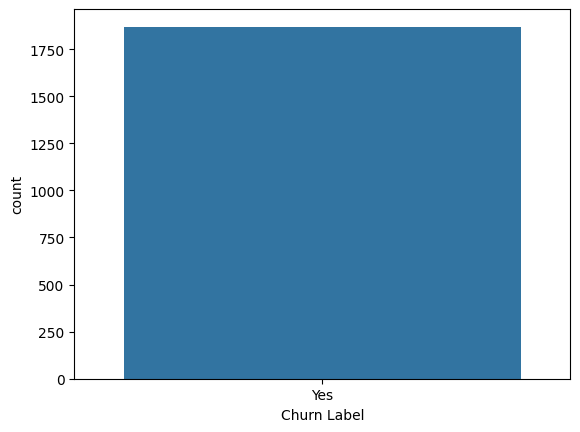

In [7]:
sns.countplot(x="Churn Label", data=df)
plt.show()

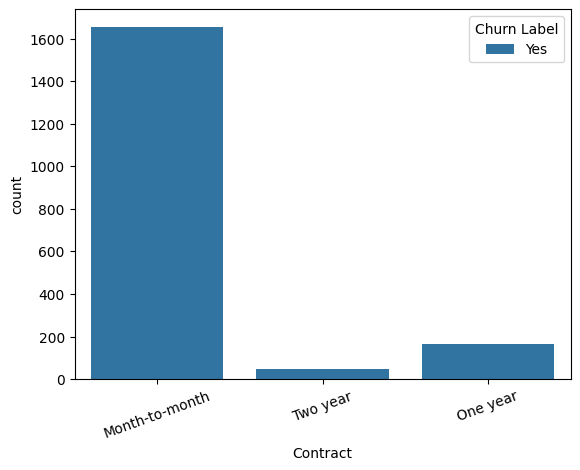

In [8]:
sns.countplot(
x="Contract",
hue="Churn Label",
data=df
)

plt.xticks(rotation=20)
plt.show()

* Monthly Charges

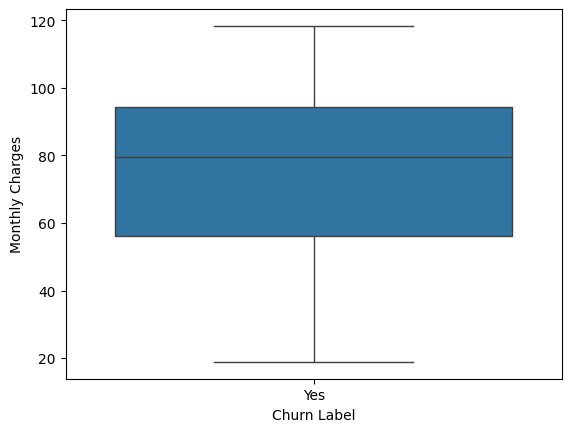

In [9]:
sns.boxplot(
x="Churn Label",
y="Monthly Charges",
data=df
)

plt.show()

6. Feature engineering

In [10]:
df = pd.get_dummies(
df,
drop_first=True
)

* Convert target variable

In [11]:
df["Churn Value"] = df["Churn Value"].astype(int)

7. Build Churn Prediction Model

* Split data

In [12]:
df_processed = df.copy()

# Ensure CustomerID is dropped if it exists
if 'CustomerID' in df_processed.columns:
    df_processed.drop("CustomerID", axis=1, inplace=True)

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, drop_first=True)

# Convert 'Churn Value' to int
df_processed["Churn Value"] = df_processed["Churn Value"].astype(int)

X = df_processed.drop("Churn Value", axis=1)
y = df_processed["Churn Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* Train model

In [13]:
model = RandomForestClassifier(
n_estimators=200,
random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

8. Evaluate model

In [14]:
predictions = model.predict(X_test)

print(
classification_report(
y_test,
predictions
)
)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       374

    accuracy                           1.00       374
   macro avg       1.00      1.00      1.00       374
weighted avg       1.00      1.00      1.00       374



* Confusion Matrix

In [15]:
cm = confusion_matrix(
y_test,
predictions
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


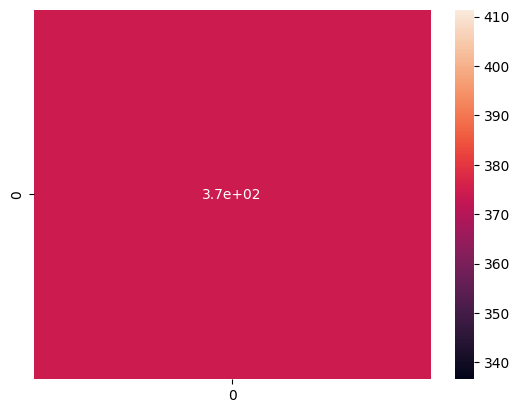

In [16]:
sns.heatmap(
cm,
annot=True
)

plt.show()

9. Feature Importance

In [17]:
importance = pd.DataFrame({
"Feature": X.columns,
"Importance": model.feature_importances_
})

In [18]:
importance = importance.sort_values(
"Importance",
ascending=False
)

print(importance.head(10))

                                   Feature  Importance
2075  Churn Reason_Service dissatisfaction         0.0
0                                    Count         0.0
1                                 Zip Code         0.0
2                                 Latitude         0.0
3                                Longitude         0.0
4                            Tenure Months         0.0
5                          Monthly Charges         0.0
6                            Total Charges         0.0
7                              Churn Score         0.0
8                                     CLTV         0.0


In [19]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

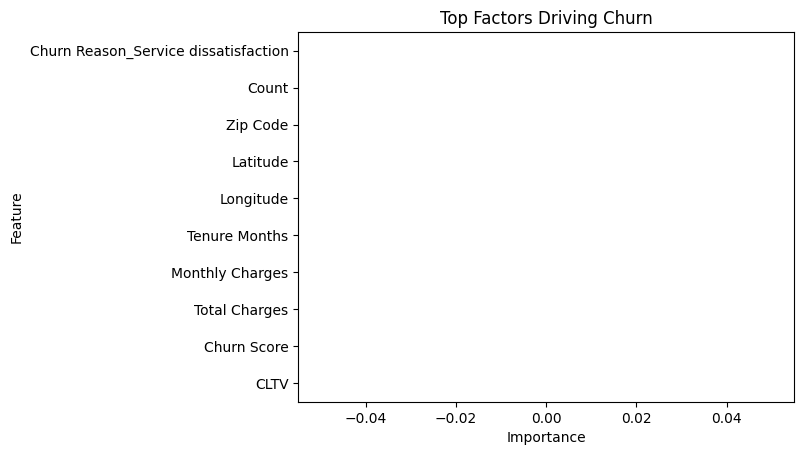

In [20]:
sns.barplot(
data=importance.head(10),
x="Importance",
y="Feature"
)

plt.title("Top Factors Driving Churn")
plt.show()

10. Business Insights

* Month-to-month contracts have the highest churn.
* Customers with short tenure are more likely to churn.
* Higher monthly charges increase churn risk.
* Fiber optic customers churn more frequently.
* Long-term contracts reduce churn.